In [1]:
import warnings
import tensorflow as tf, tensorflow_hub as hub
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

print(tf.__version__)
model = hub.load("https://tfhub.dev/google/yamnet/1")
print("✅ loaded")


C:\Users\takan\yamnet-py311\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


2.15.0


ValueError: Trying to load a model of incompatible/unknown type. 'C:\Users\takan\AppData\Local\Temp\tfhub_modules\9616fd04ec2360621642ef9455b84f4b668e219e' contains neither 'saved_model.pb' nor 'saved_model.pbtxt'.

In [12]:
import sounddevice as sd
sd.query_devices()

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
   1 CABLE Output (VB-Audio Virtual , MME (16 in, 0 out)
   2 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  3 CABLE Input (VB-Audio Virtual C, MME (0 in, 16 out)
   4 Speakers (3- High Definition Au, MME (0 in, 6 out)
   5 Digital Audio (S/PDIF) (3- High, MME (0 in, 2 out)
   6 PHL 221E9 (NVIDIA High Definiti, MME (0 in, 2 out)
   7 FxSound Speakers (FxSound Audio, MME (0 in, 8 out)
   8 CABLE In 16ch (VB-Audio Virtual, MME (0 in, 16 out)
   9 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
> 10 CABLE Output (VB-Audio Virtual Cable), Windows DirectSound (16 in, 0 out)
  11 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  12 CABLE Input (VB-Audio Virtual Cable), Windows DirectSound (0 in, 16 out)
  13 Speakers (3- High Definition Audio Device), Windows DirectSound (0 in, 6 out)
  14 Digital Audio (S/PDIF) (3- High Definition Audio Device), Windows DirectSound (0 in, 2 out)
  15 PHL 221E9 (NVIDIA High

🎙️ Streaming detection start...
Speech (0.10)


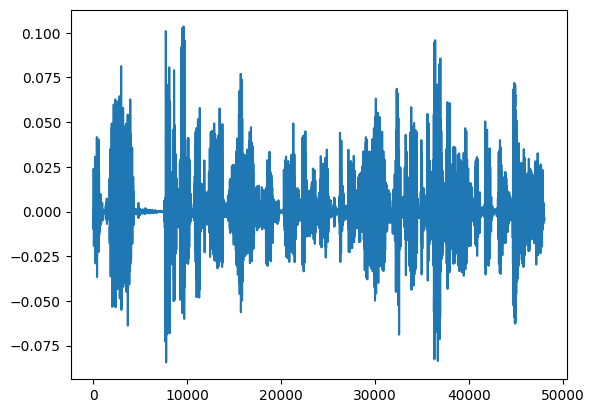

Music (0.24)


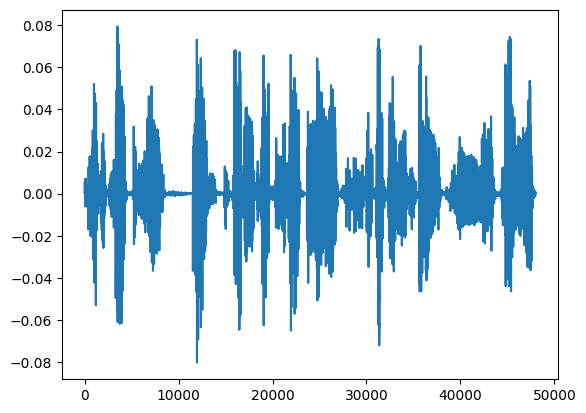

Music (0.25)


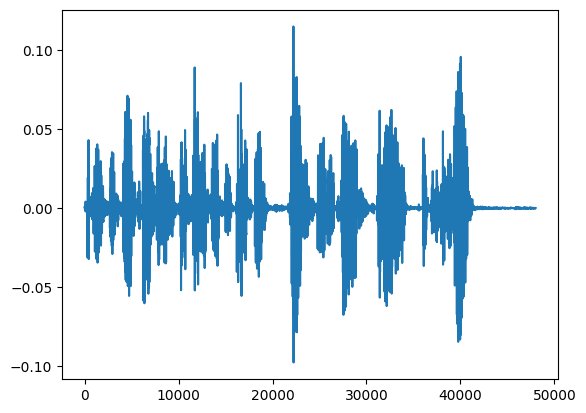

Music: 0.25
Speech: 0.24
Electronic music: 0.06
Sound effect: 0.06
Grunt: 0.05


In [23]:
import sounddevice as sd
import tensorflow as tf
import tensorflow_hub as hub
import pandas as pd
import matplotlib.pyplot as plt

# モデルとラベルを関数内で完結させる
def stream_detect(chunk=3, duration=10.0):
    sr = 16000
    sd.default.device = (24, None)
    model = hub.load("https://tfhub.dev/google/yamnet/1")
    url = "https://raw.githubusercontent.com/robertanto/Real-Time-Sound-Event-Detection/main/keras_yamnet/yamnet_class_map.csv"
    labels = pd.read_csv(url)['display_name'].tolist()

    print("🎙️ Streaming detection start...")
    with sd.InputStream(samplerate=sr, channels=1, dtype='float32') as stream:
        for _ in range(int(duration / chunk)):
            audio, _ = stream.read(int(sr * chunk))
            scores, _, _ = model(audio[:, 0])
            mean_scores = tf.reduce_mean(scores, axis=0)
            top = int(tf.argmax(mean_scores))
            label = labels[top]
            prob = float(mean_scores[top])
            print(f"{label} ({prob:.2f})")
            plt.plot(audio)
            plt.show()
    top5 = tf.argsort(mean_scores, direction='DESCENDING')[:5]
    for i in top5:
        print(f"{labels[int(i)]}: {mean_scores[i].numpy():.2f}")
stream_detect(chunk=3, duration=10.0)

